In [2]:
# importance analysis for RQ2 - inspection of zero-shot responses
import pandas as pd
from pathlib import Path
df_imp_zeroshot = pd.read_csv('../1_zero-shot/zeroshotResponses/zeroshotImportanceResponses.csv')

df_imp_zeroshot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6600 entries, 0 to 6599
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   row_id         6600 non-null   object
 1   base_model     6600 non-null   object
 2   variant_id     6600 non-null   object
 3   model          6600 non-null   object
 4   dc_solution    6600 non-null   object
 5   rating         6600 non-null   int64 
 6   label          6600 non-null   object
 7   iteration      6600 non-null   int64 
 8   timestamp      6600 non-null   object
 9   justification  6600 non-null   object
dtypes: int64(2), object(8)
memory usage: 515.8+ KB


In [3]:
# Importance analysis for RQ2 - inspection of context responses
import pandas as pd
from pathlib import Path
df_imp_cxt = pd.read_csv('../2_context/contextResponses/contextImportanceResponses.csv')

df_imp_cxt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6600 entries, 0 to 6599
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   row_id         6600 non-null   object
 1   base_model     6600 non-null   object
 2   variant_id     6600 non-null   object
 3   model          6600 non-null   object
 4   dc_solution    6600 non-null   object
 5   rating         6600 non-null   int64 
 6   label          6600 non-null   object
 7   iteration      6600 non-null   int64 
 8   timestamp      6600 non-null   object
 9   justification  6592 non-null   object
dtypes: int64(2), object(8)
memory usage: 515.8+ KB


In [4]:
# cell3: merging zeroshot and context data of feasibility responses
import pandas as pd
# create output directory
output_dir = Path('imp-ctx-zeroshot-working')
output_dir.mkdir(parents=True, exist_ok=True)

# load data
df_imp_ctx = pd.read_csv('../2_context/contextResponses/contextImportanceResponses.csv')
df_imp_zeroshot = pd.read_csv('../1_zero-shot/zeroshotResponses/zeroshotImportanceResponses.csv')

# define source and condition
df_imp_ctx['condition'] = 'context'
df_imp_zeroshot['condition'] = 'zeroshot'

# exact columns to keep
columns_to_keep = ['row_id', 'variant_id', 'base_model', 'model', 'dc_solution', 'rating', 'label', 'condition', 'iteration']

# combine the dataframes
df_combined = pd.concat([df_imp_ctx[columns_to_keep], df_imp_zeroshot[columns_to_keep]], ignore_index=True)

# save combined dataframe
df_combined.to_csv(output_dir / 'imp-ctx-zeroshot-responses.csv', index=False)

df_combined.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   row_id       13200 non-null  object
 1   variant_id   13200 non-null  object
 2   base_model   13200 non-null  object
 3   model        13200 non-null  object
 4   dc_solution  13200 non-null  object
 5   rating       13200 non-null  int64 
 6   label        13200 non-null  object
 7   condition    13200 non-null  object
 8   iteration    13200 non-null  int64 
dtypes: int64(2), object(7)
memory usage: 928.3+ KB


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


RQ2 importance forest plots saved to:
/Users/HP/Documents/second-publication/current-analysis/re-run/rq2-rerun/imp-ctx-zeroshot-working/rq2_importance_primary_forest_plot.png
/Users/HP/Documents/second-publication/current-analysis/re-run/rq2-rerun/imp-ctx-zeroshot-working/rq2_importance_primary_forest_plot.eps


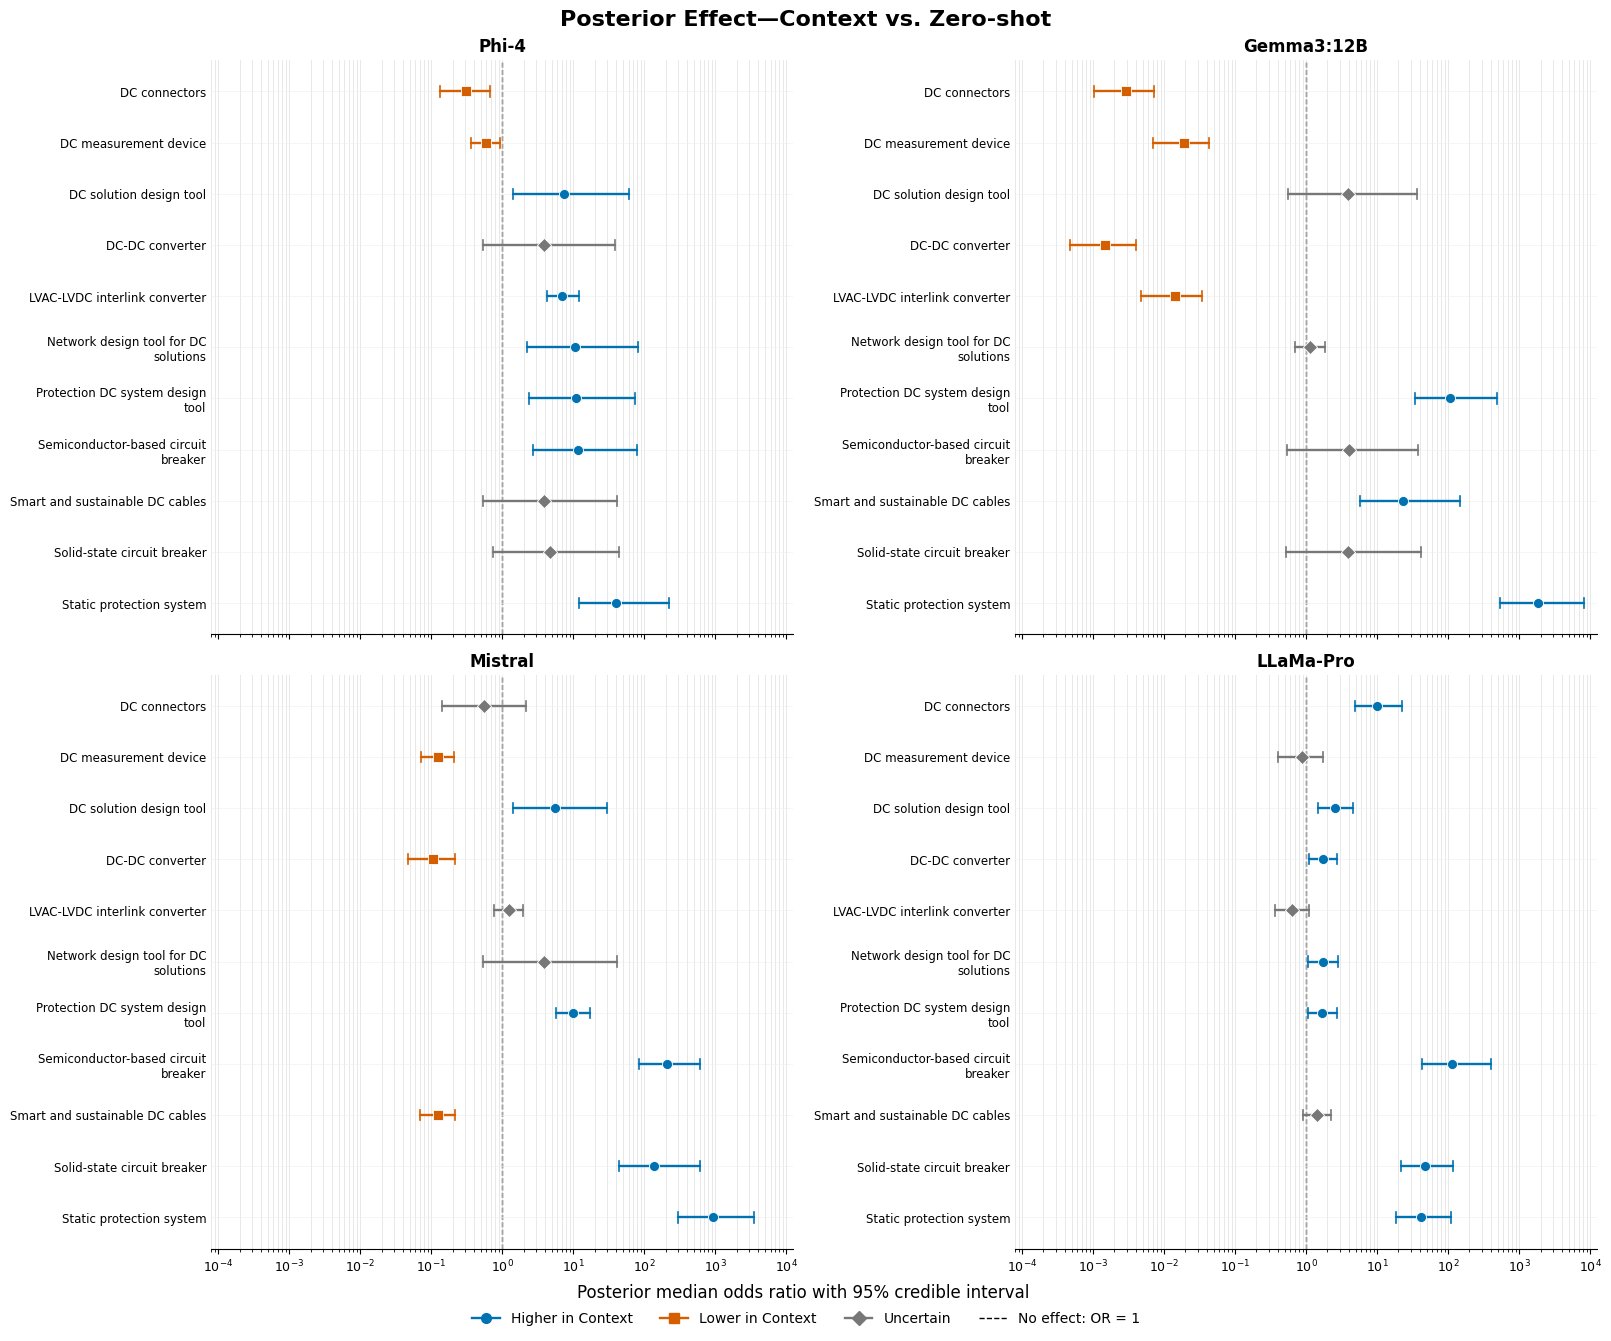

In [1]:
# latex table from primary-prior effects from the sensitivity pipeline: forest plot for main paper
from pathlib import Path
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

working_dir = Path("imp-ctx-zeroshot-working")

input_path = (
    working_dir
    / "bayesian-results"
    / "prior-sensitivity"
    / "rq2_importance_prior_sensitivity_effects.csv"
)

png_output_path = (
    working_dir
    / "rq2_importance_primary_forest_plot.png"
)

eps_output_path = (
    working_dir
    / "rq2_importance_primary_forest_plot.eps"
)

if not input_path.exists():
    raise FileNotFoundError(
        "RQ2 importance sensitivity output was not found:\n"
        f"{input_path.resolve()}"
    )

model_labels = {
    "gemma3": "Gemma3:12B",
    "llama": "LLaMa-Pro",
    "mistral": "Mistral",
    "phi4": "Phi-4",
}

model_order = [
    "phi4",
    "gemma3",
    "mistral",
    "llama",
]

style_map = {
    "higher in Context": {
        "label": "Higher in Context",
        "colour": "#0072B2",
        "marker": "o",
    },
    "lower in Context": {
        "label": "Lower in Context",
        "colour": "#D55E00",
        "marker": "s",
    },
    "uncertain": {
        "label": "Uncertain",
        "colour": "#777777",
        "marker": "D",
    },
}

# Read and validate the primary-prior effects
results = pd.read_csv(input_path)

required_columns = {
    "prior_name",
    "base_model",
    "dc_solution",
    "comparison",
    "OR_median",
    "OR_l95",
    "OR_u95",
    "conclusion",
}

missing_columns = required_columns.difference(
    results.columns
)

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(sorted(missing_columns))
    )

primary = results.loc[
    results["prior_name"].eq("primary")
].copy()

if len(primary) != 44:
    raise ValueError(
        "Expected 44 primary-prior contrasts "
        f"(4 models × 11 DC solutions), found {len(primary)}."
    )

if set(primary["base_model"]) != set(model_order):
    raise ValueError(
        "The expected four base models were not found."
    )

if primary.duplicated(
    subset=["base_model", "dc_solution"]
).any():
    raise ValueError(
        "Duplicate base-model/DC-solution contrasts were found."
    )

if not primary["comparison"].eq(
    "CONTEXT vs ZEROSHOT"
).all():
    raise ValueError(
        "Unexpected comparison labels were found."
    )

if (
    primary[
        ["OR_median", "OR_l95", "OR_u95"]
    ] <= 0
).any().any():
    raise ValueError(
        "All odds ratios and interval limits must be positive "
        "for a logarithmic forest plot."
    )

unexpected_conclusions = set(
    primary["conclusion"]
).difference(style_map)

if unexpected_conclusions:
    raise ValueError(
        "Unexpected conclusion values: "
        + ", ".join(sorted(unexpected_conclusions))
    )

# Preserve the ordering used in the analysis output
solution_order = (
    primary["dc_solution"]
    .drop_duplicates()
    .tolist()
)

primary["base_model"] = pd.Categorical(
    primary["base_model"],
    categories=model_order,
    ordered=True,
)

primary["dc_solution"] = pd.Categorical(
    primary["dc_solution"],
    categories=solution_order,
    ordered=True,
)

primary = (
    primary
    .sort_values(["base_model", "dc_solution"])
    .reset_index(drop=True)
)

# --------------------------------------------------------------
# Establish a common logarithmic x-axis
# --------------------------------------------------------------

minimum_interval = primary["OR_l95"].min()
maximum_interval = primary["OR_u95"].max()

x_min = 10 ** np.floor(
    np.log10(minimum_interval)
)

x_max = 10 ** np.ceil(
    np.log10(maximum_interval)
)

# Slight padding on a logarithmic scale
x_min = x_min / 1.25
x_max = x_max * 1.25

# Wrap long solution names
wrapped_solution_labels = {
    solution: textwrap.fill(
        str(solution),
        width=31,
    )
    for solution in solution_order
}

# --------------------------------------------------------------
# Construct the four-panel forest plot
# --------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 13),
    sharex=True,
    constrained_layout=True,
)

axes = axes.flatten()

for axis, base_model in zip(
    axes,
    model_order,
):
    model_data = (
        primary.loc[
            primary["base_model"].eq(base_model)
        ]
        .sort_values("dc_solution")
        .reset_index(drop=True)
    )

    y_positions = np.arange(
        len(model_data)
    )

    # Draw one posterior estimate and CrI at a time
    for row_number, row in model_data.iterrows():
        style = style_map[row["conclusion"]]

        # 95% credible interval
        axis.plot(
            [row["OR_l95"], row["OR_u95"]],
            [row_number, row_number],
            color=style["colour"],
            linewidth=1.7,
            solid_capstyle="round",
            zorder=2,
        )

        # Interval end caps
        axis.plot(
            [row["OR_l95"], row["OR_l95"]],
            [row_number - 0.10, row_number + 0.10],
            color=style["colour"],
            linewidth=1.2,
            zorder=2,
        )

        axis.plot(
            [row["OR_u95"], row["OR_u95"]],
            [row_number - 0.10, row_number + 0.10],
            color=style["colour"],
            linewidth=1.2,
            zorder=2,
        )

        # Posterior median OR
        axis.scatter(
            row["OR_median"],
            row_number,
            color=style["colour"],
            marker=style["marker"],
            s=52,
            edgecolor="white",
            linewidth=0.6,
            zorder=3,
        )

    # OR = 1 means no condition effect
    axis.axvline(
        1,
        color="black",
        linestyle="--",
        linewidth=1,
        alpha=0.8,
        zorder=1,
    )

    axis.set_xscale("log")
    axis.set_xlim(x_min, x_max)

    axis.set_yticks(y_positions)
    axis.set_yticklabels(
        [
            wrapped_solution_labels[str(solution)]
            for solution in model_data["dc_solution"]
        ],
        fontsize=8.5,
    )

    axis.invert_yaxis()

    axis.set_title(
        model_labels[base_model],
        fontsize=12,
        fontweight="bold",
    )

    axis.grid(
        axis="x",
        which="both",
        color="#DDDDDD",
        linewidth=0.6,
        alpha=0.8,
    )

    axis.grid(
        axis="y",
        which="major",
        color="#EEEEEE",
        linewidth=0.5,
        alpha=0.8,
    )

    axis.tick_params(
        axis="x",
        labelsize=9,
    )

    axis.tick_params(
        axis="y",
        length=0,
    )

    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["left"].set_visible(False)

# Shared labels and title
fig.suptitle(
    "Posterior Effect—Context vs. Zero-shot",
    fontsize=16,
    fontweight="bold",
)

fig.supxlabel(
    "Posterior median odds ratio with 95% credible interval ",
    fontsize=12,
)

# Actual icons in the legend
legend_handles = [
    Line2D(
        [0],
        [0],
        color=style_map["higher in Context"]["colour"],
        marker=style_map["higher in Context"]["marker"],
        linewidth=1.7,
        markersize=7,
        label="Higher in Context",
    ),
    Line2D(
        [0],
        [0],
        color=style_map["lower in Context"]["colour"],
        marker=style_map["lower in Context"]["marker"],
        linewidth=1.7,
        markersize=7,
        label="Lower in Context",
    ),
    Line2D(
        [0],
        [0],
        color=style_map["uncertain"]["colour"],
        marker=style_map["uncertain"]["marker"],
        linewidth=1.7,
        markersize=7,
        label="Uncertain",
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=1,
        label="No effect: OR = 1",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.025),
    ncol=4,
    frameon=False,
    fontsize=10,
)

# --------------------------------------------------------------
# Save both publication and inspection formats
# --------------------------------------------------------------

fig.savefig(
    png_output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    eps_output_path,
    format="eps",
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

print(
    "RQ2 importance forest plots saved to:\n"
    f"{png_output_path.resolve()}\n"
    f"{eps_output_path.resolve()}"
)

plt.show()


In [3]:
# latex table from primary-prior effects from the sensitivity pipeline: detailed 44 row latex table -> online appendix

from pathlib import Path
import pandas as pd
from IPython.display import display

# Paths relative to:
# rq2-rerun/rq2-imp-analysis.ipynb

working_dir = Path("imp-ctx-zeroshot-working")

input_path = (
    working_dir
    / "bayesian-results"
    / "prior-sensitivity"
    / "rq2_importance_prior_sensitivity_effects.csv"
)

output_path = (
    working_dir
    / "rq2_importance_primary_appendix_table.tex"
)

if not input_path.exists():
    raise FileNotFoundError(
        "RQ2 importance sensitivity output was not found:\n"
        f"{input_path.resolve()}"
    )

model_labels = {
    "gemma3": "Gemma3:12B",
    "llama": "LLaMa-Pro",
    "mistral": "Mistral",
    "phi4": "Phi-4",
}

model_order = [
    "gemma3",
    "llama",
    "mistral",
    "phi4",
]

conclusion_labels = {
    "higher in Context": "Higher in Context",
    "lower in Context": "Lower in Context",
    "uncertain": "Uncertain",
}


def format_estimate(value):
    """
    Use scientific notation for values that would otherwise
    be rounded to zero or occupy excessive table space.
    """
    value = float(value)

    if value != 0 and (
        abs(value) < 0.001 or abs(value) >= 1000
    ):
        mantissa, exponent = f"{value:.2e}".split("e")

        return (
            rf"${mantissa}\times "
            rf"10^{{{int(exponent)}}}$"
        )

    return f"{value:.3f}"


def format_probability(value):
    """
    Avoid reporting posterior probabilities as exact zero or one.
    """
    value = float(value)

    if value >= 0.9995:
        return r"$>0.999$"

    if value <= 0.0005:
        return r"$<0.001$"

    return f"{value:.3f}"


# --------------------------------------------------------------
# Read and select the primary-prior results
# --------------------------------------------------------------

results = pd.read_csv(input_path)

required_columns = {
    "prior_name",
    "base_model",
    "dc_solution",
    "comparison",
    "OR_median",
    "OR_l95",
    "OR_u95",
    "posterior_probability_OR_gt_1",
    "conclusion",
}

missing_columns = required_columns.difference(
    results.columns
)

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(sorted(missing_columns))
    )

primary = results.loc[
    results["prior_name"].eq("primary")
].copy()

if len(primary) != 44:
    raise ValueError(
        "Expected 44 primary-prior contrasts "
        f"(4 models × 11 DC solutions), found {len(primary)}."
    )

if set(primary["base_model"]) != set(model_order):
    raise ValueError(
        "The expected four base models were not found."
    )

if primary.duplicated(
    subset=["base_model", "dc_solution"]
).any():
    raise ValueError(
        "Duplicate base-model/DC-solution contrasts were found."
    )

if not primary["comparison"].eq(
    "CONTEXT vs ZEROSHOT"
).all():
    raise ValueError(
        "Unexpected comparison labels were found."
    )

# Preserve the solution order used in the output
solution_order = (
    primary["dc_solution"]
    .drop_duplicates()
    .tolist()
)

primary["base_model"] = pd.Categorical(
    primary["base_model"],
    categories=model_order,
    ordered=True,
)

primary["dc_solution"] = pd.Categorical(
    primary["dc_solution"],
    categories=solution_order,
    ordered=True,
)

primary = (
    primary
    .sort_values(["base_model", "dc_solution"])
    .reset_index(drop=True)
)

# --------------------------------------------------------------
# Construct the table
# --------------------------------------------------------------

table = pd.DataFrame({
    "Model": (
        primary["base_model"]
        .astype("object")
        .map(model_labels)
    ),

    "DC solution": (
        primary["dc_solution"]
        .astype("object")
    ),

    "OR": primary["OR_median"].map(
        format_estimate
    ),

    r"95\% CrI": [
        (
            f"[{format_estimate(lower)}, "
            f"{format_estimate(upper)}]"
        )
        for lower, upper in zip(
            primary["OR_l95"],
            primary["OR_u95"],
        )
    ],

    r"$P(\mathrm{OR}>1)$": primary[
        "posterior_probability_OR_gt_1"
    ].map(format_probability),

    "Interpretation": primary["conclusion"].map(
        conclusion_labels
    ),
})

if table.isna().any().any():
    raise ValueError(
        "Missing values were produced while constructing "
        "the appendix table."
    )

# Number only the notebook display.
# The index is excluded from the LaTeX output.
table.index = range(1, len(table) + 1)
table.index.name = None

# --------------------------------------------------------------
# Generate a multipage longtable
# --------------------------------------------------------------

latex = table.to_latex(
    index=False,
    escape=False,
    longtable=True,
    column_format=(
        r"p{2.3cm}"
        r"p{5.0cm}"
        r"c"
        r"c"
        r"c"
        r"p{3.2cm}"
    ),
    caption=(
        "RQ2 importance: posterior effects of Context relative "
        "to Zero-shot for each base model and DC solution under "
        "the primary prior."
    ),
    label="tab:rq2_importance_bayesian_appendix",
    position="tbp",
)

note = (
    "\n"
    "\\noindent\\begin{minipage}{\\linewidth}\n"
    "\\footnotesize\\textit{Note.} "
    "Each row represents a separately estimated "
    "base-model/DC-solution contrast; the odds ratios were not "
    "pooled across DC solutions. "
    "OR $>1$ indicates higher odds of receiving a higher "
    "importance rating in Context relative to Zero-shot, whereas "
    "OR $<1$ indicates lower odds in Context. "
    "CrI denotes the 95\\% Bayesian credible interval. "
    "$P(\\mathrm{OR}>1)$ denotes the posterior probability that "
    "the odds ratio exceeds one. "
    "The primary effect prior was Normal$(0,1.5)$.\n"
    "\\end{minipage}\n"
)

latex = latex + note

output_path.write_text(
    latex,
    encoding="utf-8",
)

print(
    "RQ2 importance appendix table saved to:\n"
    f"{output_path.resolve()}"
)

print(f"Contrasts reported: {len(table)}")

display(table)


RQ2 importance appendix table saved to:
/Users/HP/Documents/second-publication/current-analysis/re-run/rq2-rerun/imp-ctx-zeroshot-working/rq2_importance_primary_appendix_table.tex
Contrasts reported: 44


,Model,DC solution,OR,95\% CrI,$P(\mathrm{OR}>1)$,Interpretation
1,Gemma3:12B,DC connectors,0.003,"[0.001, 0.007]",$<0.001$,Lower in Context
2,Gemma3:12B,DC measurement device,0.019,"[0.007, 0.043]",$<0.001$,Lower in Context
3,Gemma3:12B,DC solution design tool,3.916,"[0.552, 36.900]",0.903,Uncertain
4,Gemma3:12B,DC-DC converter,0.001,"[$4.71\times 10^{-4}$, 0.004]",$<0.001$,Lower in Context
5,Gemma3:12B,LVAC-LVDC interlink converter,0.014,"[0.005, 0.034]",$<0.001$,Lower in Context
6,Gemma3:12B,Network design tool for DC solutions,1.129,"[0.688, 1.874]",0.675,Uncertain
7,Gemma3:12B,Protection DC system design tool,106.152,"[33.825, 490.424]",$>0.999$,Higher in Context
8,Gemma3:12B,Semiconductor-based circuit breaker,3.967,"[0.539, 37.652]",0.912,Uncertain
9,Gemma3:12B,Smart and sustainable DC cables,23.185,"[5.659, 147.700]",$>0.999$,Higher in Context
10,Gemma3:12B,Solid-state circuit breaker,3.862,"[0.530, 41.682]",0.910,Uncertain


In [4]:
# primary-model ppc results for RQ2 importance: online appendix reporting, compact diagnostic table for the online appendix
from pathlib import Path
import pandas as pd
from IPython.display import display

working_dir = Path("imp-ctx-zeroshot-working")

input_path = (
    working_dir
    / "bayesian-results"
    / "base-solution-threshold"
    / "posterior-predictive-checks"
    / "rq2_importance_base_solution_threshold_ppc_summary.csv"
)

output_path = (
    working_dir
    / "rq2_importance_primary_ppc_summary_table.tex"
)

if not input_path.exists():
    raise FileNotFoundError(
        "RQ2 importance primary-model PPC summary was not found:\n"
        f"{input_path.resolve()}"
    )

model_labels = {
    "gemma3": "Gemma3:12B",
    "llama": "LLaMa-Pro",
    "mistral": "Mistral",
    "phi4": "Phi-4",
    "all": "Overall",
}

model_order = [
    "phi4",
    "gemma3",
    "mistral",
    "llama",
    "all",
]

# --------------------------------------------------------------
# Read and validate the PPC summary
# --------------------------------------------------------------

ppc = pd.read_csv(input_path)

required_columns = {
    "base_model",
    "category_checks",
    "checks_within_predictive_95",
    "proportion_within_predictive_95",
    "median_absolute_difference",
    "maximum_absolute_difference",
}

missing_columns = required_columns.difference(
    ppc.columns
)

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(sorted(missing_columns))
    )

if set(ppc["base_model"]) != set(model_order):
    raise ValueError(
        "The PPC summary does not contain the expected "
        "four base models and overall row."
    )

if len(ppc) != 5:
    raise ValueError(
        f"Expected five PPC summary rows, found {len(ppc)}."
    )

ppc["base_model"] = pd.Categorical(
    ppc["base_model"],
    categories=model_order,
    ordered=True,
)

ppc = (
    ppc
    .sort_values("base_model")
    .reset_index(drop=True)
)

# Construct the compact diagnostic table
table = pd.DataFrame({
    "Model": (
        ppc["base_model"]
        .astype("object")
        .map(model_labels)
    ),

    "Within 95\\% PPI": [
        f"{within}/{total}"
        for within, total in zip(
            ppc["checks_within_predictive_95"],
            ppc["category_checks"],
        )
    ],

    "Coverage": ppc[
        "proportion_within_predictive_95"
    ].map(
        lambda value: f"{100 * value:.1f}\\%"
    ),

    "Median absolute difference": ppc[
        "median_absolute_difference"
    ].map(
        lambda value: f"{value:.3f}"
    ),

    "Maximum absolute difference": ppc[
        "maximum_absolute_difference"
    ].map(
        lambda value: f"{value:.3f}"
    ),
})

if table.isna().any().any():
    raise ValueError(
        "Missing values were produced while constructing "
        "the PPC table."
    )

# Number the notebook display from 1 to 5.
# The index is excluded from the LaTeX table.
table.index = range(1, len(table) + 1)
table.index.name = None

# Generate the LaTeX table
latex = table.to_latex(
    index=False,
    escape=False,
    column_format="lcccc",
    caption=(
        "Posterior predictive checks for the RQ2 importance "
        "primary model."
    ),
    label="tab:rq2_importance_primary_ppc",
    position="tbp",
)

note = (
    "\\end{tabular}\n"
    "\\vspace{2pt}\n"
    "\\begin{minipage}{\\linewidth}\n"
    "\\footnotesize\\textit{Note.} "
    "PPI denotes the 95\\% posterior predictive interval. "
    "Coverage is the proportion of observed rating-category "
    "proportions that fell within their corresponding PPIs. "
    "Absolute differences compare the observed rating-category "
    "proportions with the posterior-predicted median proportions. "
    "Each base model contributed 66 checks: 11 DC solutions "
    "$\\times$ 2 conditions $\\times$ 3 observed rating "
    "categories. The overall row contains all 264 checks.\n"
    "\\end{minipage}"
)

latex = latex.replace(
    "\\end{tabular}",
    note,
    1,
)

output_path.write_text(
    latex,
    encoding="utf-8",
)

print(
    "RQ2 importance primary-model PPC table saved to:\n"
    f"{output_path.resolve()}"
)

display(table)

RQ2 importance primary-model PPC table saved to:
/Users/HP/Documents/second-publication/current-analysis/re-run/rq2-rerun/imp-ctx-zeroshot-working/rq2_importance_primary_ppc_summary_table.tex


,Model,Within 95\% PPI,Coverage,Median absolute difference,Maximum absolute difference
1,Phi-4,66/66,100.0\%,0.007,0.013
2,Gemma3:12B,59/66,89.4\%,0.007,0.053
3,Mistral,66/66,100.0\%,0.007,0.033
4,LLaMa-Pro,66/66,100.0\%,0.005,0.020
5,Overall,257/264,97.3\%,0.007,0.053


In [5]:
# sensitivity results comparisons for rq2 importance: online appendix reporting.
from pathlib import Path
import pandas as pd
from IPython.display import display

working_dir = Path("imp-ctx-zeroshot-working")

input_path = (
    working_dir
    / "bayesian-results"
    / "prior-sensitivity"
    / "rq2_importance_prior_sensitivity_robustness.csv"
)

summary_output_path = (
    working_dir
    / "rq2_importance_prior_sensitivity_summary_table.tex"
)

exceptions_output_path = (
    working_dir
    / "rq2_importance_prior_sensitive_contrasts_table.tex"
)

if not input_path.exists():
    raise FileNotFoundError(
        f"Robustness results not found:\n{input_path.resolve()}"
    )

model_labels = {
    "gemma3": "Gemma3:12B",
    "llama": "LLaMa-Pro",
    "mistral": "Mistral",
    "phi4": "Phi-4",
}

model_order = [
    "phi4",
    "gemma3",
    "mistral",
    "llama",
]

conclusion_labels = {
    "higher in Context": "Higher in Context",
    "lower in Context": "Lower in Context",
    "uncertain": "Uncertain",
}


def format_number(value):
    value = float(value)

    if value != 0 and (
        abs(value) < 0.001 or abs(value) >= 1000
    ):
        mantissa, exponent = f"{value:.2e}".split("e")
        return (
            rf"${mantissa}\times 10^{{{int(exponent)}}}$"
        )

    return f"{value:.3f}"


def format_prior_result(row, prior_name):
    estimate = format_number(
        row[f"OR_median_{prior_name}"]
    )
    lower = format_number(
        row[f"OR_l95_{prior_name}"]
    )
    upper = format_number(
        row[f"OR_u95_{prior_name}"]
    )
    conclusion = conclusion_labels[
        row[f"conclusion_{prior_name}"]
    ]

    return (
        f"{estimate} [{lower}, {upper}]; "
        f"{conclusion}"
    )


robustness = pd.read_csv(input_path)

required_columns = {
    "base_model",
    "dc_solution",
    "OR_median_regularizing",
    "OR_l95_regularizing",
    "OR_u95_regularizing",
    "OR_median_primary",
    "OR_l95_primary",
    "OR_u95_primary",
    "OR_median_weak",
    "OR_l95_weak",
    "OR_u95_weak",
    "conclusion_regularizing",
    "conclusion_primary",
    "conclusion_weak",
    "direction_stable",
    "conclusion_stable",
}

missing_columns = required_columns.difference(
    robustness.columns
)

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(sorted(missing_columns))
    )

if len(robustness) != 44:
    raise ValueError(
        "Expected 44 robustness rows, "
        f"found {len(robustness)}."
    )

# Ensure logical columns are genuinely logical
for column in [
    "direction_stable",
    "conclusion_stable",
]:
    if robustness[column].dtype != bool:
        robustness[column] = (
            robustness[column]
            .astype(str)
            .str.upper()
            .map({"TRUE": True, "FALSE": False})
        )

    if robustness[column].isna().any():
        raise ValueError(
            f"Could not interpret {column} as logical."
        )

# --------------------------------------------------------------
# Table 1: model-level stability summary
# --------------------------------------------------------------

summary_records = []

for base_model in model_order:
    model_data = robustness.loc[
        robustness["base_model"].eq(base_model)
    ]

    total = len(model_data)
    direction_count = int(
        model_data["direction_stable"].sum()
    )
    conclusion_count = int(
        model_data["conclusion_stable"].sum()
    )

    summary_records.append({
        "Model": model_labels[base_model],
        "Contrasts": total,
        "Direction stable": (
            f"{direction_count}/{total} "
            f"({100 * direction_count / total:.1f}\\%)"
        ),
        "Conclusion stable": (
            f"{conclusion_count}/{total} "
            f"({100 * conclusion_count / total:.1f}\\%)"
        ),
    })

total = len(robustness)
direction_count = int(
    robustness["direction_stable"].sum()
)
conclusion_count = int(
    robustness["conclusion_stable"].sum()
)

summary_records.append({
    "Model": "Overall",
    "Contrasts": total,
    "Direction stable": (
        f"{direction_count}/{total} "
        f"({100 * direction_count / total:.1f}\\%)"
    ),
    "Conclusion stable": (
        f"{conclusion_count}/{total} "
        f"({100 * conclusion_count / total:.1f}\\%)"
    ),
})

summary_table = pd.DataFrame(summary_records)

summary_latex = summary_table.to_latex(
    index=False,
    escape=False,
    column_format="lccc",
    caption=(
        "Prior-sensitivity summary for the RQ2 importance "
        "condition effects."
    ),
    label="tab:rq2_importance_prior_sensitivity_summary",
    position="tbp",
)

summary_note = (
    "\\end{tabular}\n"
    "\\vspace{2pt}\n"
    "\\begin{minipage}{\\linewidth}\n"
    "\\footnotesize\\textit{Note.} "
    "Direction stability indicates that the posterior median OR "
    "remained on the same side of one under the regularizing, "
    "primary, and weak priors. Conclusion stability indicates "
    "that the inferential classification was identical under all "
    "three priors. Rates were recalculated directly from the 44 "
    "contrast-level robustness records.\n"
    "\\end{minipage}"
)

summary_latex = summary_latex.replace(
    "\\end{tabular}",
    summary_note,
    1,
)

summary_output_path.write_text(
    summary_latex,
    encoding="utf-8",
)

# --------------------------------------------------------------
# Table 2: only prior-sensitive contrasts
# --------------------------------------------------------------

exceptions = robustness.loc[
    ~robustness["conclusion_stable"]
    | ~robustness["direction_stable"]
].copy()

model_rank = {
    model: rank
    for rank, model in enumerate(model_order)
}

exceptions["_model_order"] = exceptions[
    "base_model"
].map(model_rank)

exceptions = (
    exceptions
    .sort_values(["_model_order", "dc_solution"])
    .reset_index(drop=True)
)

if exceptions.empty:
    exceptions_table = pd.DataFrame({
        "Result": [
            "All 44 contrasts were stable across priors."
        ]
    })
else:
    exceptions_table = pd.DataFrame({
        "Model": exceptions["base_model"].map(
            model_labels
        ),

        "DC solution": exceptions["dc_solution"],

        "Regularizing OR (95\\% CrI); conclusion": [
            format_prior_result(row, "regularizing")
            for _, row in exceptions.iterrows()
        ],

        "Primary OR (95\\% CrI); conclusion": [
            format_prior_result(row, "primary")
            for _, row in exceptions.iterrows()
        ],

        "Weak OR (95\\% CrI); conclusion": [
            format_prior_result(row, "weak")
            for _, row in exceptions.iterrows()
        ],
    })

exceptions_latex = exceptions_table.to_latex(
    index=False,
    escape=False,
    column_format=(
        r"p{2.0cm}"
        r"p{4.0cm}"
        r"p{4.0cm}"
        r"p{4.0cm}"
        r"p{4.0cm}"
    ),
    caption=(
        "RQ2 importance contrasts whose conclusions were "
        "sensitive to the prior specification."
    ),
    label="tab:rq2_importance_prior_sensitive_contrasts",
    position="tbp",
)

exceptions_note = (
    "\\end{tabular}\n"
    "\\vspace{2pt}\n"
    "\\begin{minipage}{\\linewidth}\n"
    "\\footnotesize\\textit{Note.} "
    "Cells report the posterior median OR, 95\\% credible "
    "interval, and inferential conclusion under each prior. "
    "Only contrasts for which either direction or conclusion "
    "changed across priors are shown.\n"
    "\\end{minipage}"
)

exceptions_latex = exceptions_latex.replace(
    "\\end{tabular}",
    exceptions_note,
    1,
)

exceptions_output_path.write_text(
    exceptions_latex,
    encoding="utf-8",
)

print("RQ2 importance sensitivity tables saved to:")
print(summary_output_path.resolve())
print(exceptions_output_path.resolve())

print("\nModel-level stability summary:")
display(summary_table)

print("\nPrior-sensitive contrasts:")
display(exceptions_table)

RQ2 importance sensitivity tables saved to:
/Users/HP/Documents/second-publication/current-analysis/re-run/rq2-rerun/imp-ctx-zeroshot-working/rq2_importance_prior_sensitivity_summary_table.tex
/Users/HP/Documents/second-publication/current-analysis/re-run/rq2-rerun/imp-ctx-zeroshot-working/rq2_importance_prior_sensitive_contrasts_table.tex

Model-level stability summary:


,Model,Contrasts,Direction stable,Conclusion stable
0,Phi-4,11,11/11 (100.0\%),9/11 (81.8\%)
1,Gemma3:12B,11,11/11 (100.0\%),11/11 (100.0\%)
2,Mistral,11,11/11 (100.0\%),11/11 (100.0\%)
3,LLaMa-Pro,11,11/11 (100.0\%),11/11 (100.0\%)
4,Overall,44,44/44 (100.0\%),42/44 (95.5\%)



Prior-sensitive contrasts:


,Model,DC solution,Regularizing OR (95\% CrI); conclusion,Primary OR (95\% CrI); conclusion,Weak OR (95\% CrI); conclusion
0,Phi-4,DC solution design tool,"2.688 [0.916, 8.645]; Uncertain","7.443 [1.440, 61.240]; Higher in Context","19.242 [2.065, 622.900]; Higher in Context"
1,Phi-4,Solid-state circuit breaker,"1.980 [0.570, 7.026]; Uncertain","4.701 [0.751, 43.782]; Uncertain","12.196 [1.115, 456.846]; Higher in Context"


Table 1 answers: “How many conclusions were stable?”
Table 2 answers: “Which conclusions were not stable, and how did they change?”

Effect direction was stable for all 44 contrasts, while inferential conclusions were stable for 42 contrasts (95.5%). The two prior-dependent conclusions concerned Phi-4 for the DC solution design tool and solid-state circuit breaker.